### **Submission rules**:
1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file). Please make a copy of this notebook for your team. Make sure you opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **lms**.
2. Please execute all the cells before submission; make sure there are no errors, everything has been generated, and all numerical answers calculated.
3. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
4. You also need to provide a work breakdown structure estimating the efforts of each team member. Please provide it at the top of your notebook. If you do not provide the work breakdown, the points will be reducted from your work.
5. The final deadline is specified on LMS.

**IMPORTANT**: If you submit your assignment after this time and date, it will not be graded.

# Image compression with SVD

The singular value decomposition of a matrix A is the factorization of A into the
product of three matrices:
\begin{align}
 A = UDV^T,
 \end{align}
where the columns of U and V are orthonormal and
the matrix D is diagonal with positive real entries. The SVD is useful in many tasks. First, in many applications, the data matrix A is close to a
matrix of low rank and it is useful to find a low rank matrix which is a good approximation
to the data matrix. You will show that from the singular value decomposition of A, we can get the matrix B of rank k which best approximates A; in fact, we can do this for every
k. Also, singular value decomposition is defined for all matrices (rectangular or square) unlike spectral decomposition, although the latter one is used more commonly in Linear Algebra.

Considering that any image can be represented as a rectangular matrix, you can find the best rank k approximation of this image using SVD. The idea is that by significantly reducing the storage space, you can still preserve a very good quality of the image

In [2]:
try:
    from google.colab.patches import cv2_imshow
except ImportError:
    import matplotlib.pyplot as plt
    from IPython.display import display, clear_output
    def cv2_imshow(img):
        arr = img.astype('uint8') if img.dtype != 'uint8' else img
        if arr.ndim == 3:
            arr = arr[:, :, ::-1]  # BGR -> RGB
        # Close any previous figure so repeated calls (e.g. the slider)
        # don't pile up matplotlib state.
        plt.close('all')
        fig = plt.figure(figsize=(6, 6))
        plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
        plt.axis('off')
        plt.show()
import cv2 as cv
import numpy as np
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widget


### SVD implementation (0.5)

Implement a function to compute SVD of the matrix.

Do not use the built-in functions; instead, compare your solution with the built-in one.

*Hint:* one of the simpliest methods for finding eigenvalues and eigenvectors of the matrix is [Power Iteration](https://en.wikipedia.org/wiki/Power_iteration). Hovewer, you may try some advanced methods :)

In [3]:
def power_iteration(A, num_iterations=1000, tol=1e-10):
    n = A.shape[0]
    b = np.random.rand(n)
    b = b / np.linalg.norm(b)

    eigenvalue = 0.0
    for _ in range(num_iterations):
        b_new = A @ b
        eigenvalue_new = np.dot(b, b_new)
        b_new_norm = np.linalg.norm(b_new)
        if b_new_norm < 1e-14:
            break
        b_new = b_new / b_new_norm
        if abs(eigenvalue_new - eigenvalue) < tol:
            eigenvalue = eigenvalue_new
            b = b_new
            break
        eigenvalue = eigenvalue_new
        b = b_new

    eigenvalue = float(np.dot(b, A @ b))
    return eigenvalue, b

def svd(A, num_iterations=1000, tol=1e-12):
    m, n = A.shape
    k = min(m, n)
    if k == n:
        G = A.T @ A
    else:
        G = A @ A.T

    singular_values = []
    V_cols = []
    G_deflated = G.copy()

    for i in range(n):
        eigval, eigvec = power_iteration(G_deflated, num_iterations, tol)
        if eigval < 0:
            eigval = 0.0
        singular_values.append(np.sqrt(eigval))
        V_cols.append(eigvec)
        G_deflated = G_deflated - eigval * np.outer(eigvec, eigvec)
  
    order = np.argsort(singular_values)[::-1]
    singular_values = [singular_values[i] for i in order]
    V_cols = [V_cols[i] for i in order]
    Sigma_vals = np.array(singular_values)

    V_raw = np.column_stack(V_cols)
    V_full, R = np.linalg.qr(V_raw)
    for i in range(n):
        if R[i, i] < 0:
            V_full[:, i] *= -1
    V = V_full

    U_cols = []
    for i in range(n):
        sigma = Sigma_vals[i]
        if sigma > tol:
            u = (A @ V_cols[i]) / sigma
        else:
            u = np.zeros(m)
        U_cols.append(u)
 
    U_partial = np.column_stack(U_cols)

    if m != n:
        extra = np.random.rand(m, m)
        U_full, _ = np.linalg.qr(np.hstack([U_partial, extra])[:, :m])
        for i in range(k):
            if Sigma_vals[i] > tol:
                if np.dot(U_full[:, i], U_partial[:, i]) < 0:
                    U_full[:, i] *= -1
        U = U_full
    else:
        U = U_partial

    Sigma = np.zeros((m, n))
    for i in range(k):
        Sigma[i, i] = Sigma_vals[i]

    return U, Sigma, V.T

Explain in detailes the chosen method for finding SVD.


---

The chosen method is **Power Iteration with Deflation**.

### Key idea
SVD of $A$ is defined as $A = U\Sigma V^T$, where columns of $V$ are eigenvectors of $A^T A$, columns of $U$ are eigenvectors of $A A^T$, and singular values are $\sigma_i = \sqrt{\lambda_i}$.  
To avoid working with a large matrix, we choose which Gram matrix to diagonalize based on the shape of $A$:

* k = min(m, n)
* If k = n: G = A^T A (used when n \le m)
* Else: G = A A^T (used when m < n)

This ensures Power Iteration always runs on the smaller of the two symmetric matrices, reducing computational cost. Eigenvectors of the chosen $G$ give us either the right singular vectors $V$ (if $G = A^T A$) or the left singular vectors $U$ (if $G = A A^T$), and the other set is recovered via $u_i = \frac{A v_i}{\sigma_i}$ or $v_i = \frac{A^T u_i}{\sigma_i}$.

### Power Iteration
For a symmetric PSD matrix $G$, Power Iteration finds the dominant eigenpair $(\lambda_1, v_1)$:
1. Initialize a random unit vector $b_0$.
2. Repeatedly apply: $b_{k+1} = \frac{G b_k}{\|G b_k\|}$.
3. Estimate the eigenvalue via the Rayleigh quotient: $\lambda \approx b^T G b$.
4. Stop when $|\lambda_{new} - \lambda_{old}| < \text{tolerance}$.

Convergence rate is geometric with ratio $(\lambda_2/\lambda_1)^k$ — the larger the gap between the two biggest eigenvalues, the faster it converges.

### Deflation
After finding $(\lambda_1, v_1)$, the component is subtracted from $G$:
$$G \leftarrow G - \lambda_1 v_1 v_1^T$$
This zeros out the first eigenvalue, so the next Power Iteration converges to $(\lambda_2, v_2)$, and so on for all $k$ eigenpairs.

### Final assembly
* **Singular values:** $\sigma_i = \sqrt{\lambda_i}$.
* **If $G = A^T A$:** right vectors $v_i$ are direct, left vectors $u_i = \frac{A v_i}{\sigma_i}$.
* **If $G = A A^T$:** left vectors $u_i$ are direct, right vectors $v_i = \frac{A^T u_i}{\sigma_i}$.
* Full $U$ and $V$ matrices are completed via QR orthogonalization.



---



Explain why finding the roots of characteristic polynomial for finding eigenvalues is not always the best choice.

---


For an n×n matrix, eigenvalues are defined as roots of det(A − λI) = 0, which expands into a degree-n polynomial. While this works perfectly on paper, in practice it has serious issues:

1. When you expand det(A − λI), the resulting coefficients can be huge numbers, even if the eigenvalues themselves are small. A tiny floating-point rounding error in one coefficient can shift the roots significantly. Example: a 20×20 matrix with eigenvalues {1, 2, ..., 20} where changing one coefficient by 2⁻²³ moves some roots by several units.

2. No formula for n ≥ 5. For polynomials of degree 5 and higher, there is no general algebraic solution. So you are forced to use iterative numerical root-finding anyway — which introduces additional errors.

3. Computing the full characteristic polynomial first and then finding its roots is doing the work twice. Iterative methods like Power Iteration or QR algorithm find eigenvalues directly from the matrix in O(n³) operations, without the intermediate polynomial step.

4. If two eigenvalues are close to each other, the polynomial is nearly flat near that root, making numerical solvers converge very slowly or fail entirely.


---


### SVD of symmetric matrices (0.5 pts)

Here you have a symmetric matrix A. Compute a full SVD of this matrix.

In [4]:
A = np.array([[1, 2, 3, 4], [2, 7, 4, 5], [3, 4, 3, 8], [4, 5, 8, 3]], dtype=float)

U, s, Vt = svd(A)

U_np, s_np, Vt_np = np.linalg.svd(A)

print("Our SVD")
print("U:\n", U)
print("Singular values:", s)
print("V^T:\n", Vt)

print("\nNumPy SVD")
print("Singular values:", s_np)

D = np.diag(s)
A_reconstructed = U @ D @ Vt
print("\nReconstructed matrix A:")
print(np.round(A_reconstructed, 6))
print("\nOriginal matrix A:")
print(A)
print("\nMax reconstruction error:", np.max(np.abs(A - A_reconstructed)))

Our SVD
U:
 [[-0.30461046 -0.14903379 -0.31295055 -0.88716591]
 [-0.54242371 -0.07127124  0.83165076 -0.09515223]
 [-0.53433563 -0.64331012 -0.35591771  0.41708524]
 [-0.57225381  0.74757035 -0.28938132  0.17298151]]
Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]
V^T:
 [[-0.30461046 -0.54242371 -0.53433563 -0.57225381]
 [ 0.14903379  0.07127124  0.64331012 -0.74757035]
 [-0.31295055  0.83165076 -0.35591771 -0.28938132]
 [ 0.88716591  0.09515223 -0.41708524 -0.17298151]]

NumPy SVD
Singular values: [17.33847234  5.15839249  2.79573697  0.97581683]

Reconstructed matrix A:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]

Original matrix A:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]

Max reconstruction error: 3.1086244689504383e-15


Explain what matrices did you get as a result. What can you say about singular values of this matrix (about its eigenvalues)?

As a result of SVD decomposition of matrix $A$, we obtain three matrices $U$, $\Sigma$, $V^T$ such that:

$$A = U \Sigma V^T$$

**Matrix $U$** is an $m \times m$ orthogonal matrix whose columns are called **left singular vectors** of $A$. Orthogonality means:

$$U^T U = U U^T = I$$

**Matrix $\Sigma$** is an $m \times n$ diagonal matrix with non-negative real entries $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$ on the diagonal, called **singular values** of $A$. In our case $A$ is $4 \times 4$, so $\Sigma$ is also $4 \times 4$.

**Matrix $V^T$** is an $n \times n$ orthogonal matrix whose rows are called **right singular vectors** of $A$:

$$V^T V = V V^T = I$$

Since $A$ is **symmetric** ($A = A^T$), a special relationship holds between $U$ and $V$. Recall that singular values are defined as square roots of eigenvalues of $A^T A$:

$$\sigma_i = \sqrt{\lambda_i(A^T A)}$$

But since $A = A^T$, we have $A^T A = A^2$, so:

$$\sigma_i = \sqrt{\lambda_i(A^2)} = |\lambda_i(A)|$$

Therefore, **singular values of a symmetric matrix equal the absolute values of its eigenvalues**.

Furthermore, since $A$ is symmetric, the left and right singular vectors coincide (up to sign):

$$U = V$$

which means $V^T = U^T$, and the decomposition becomes:

$$A = U \Sigma U^T$$

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(A)

idx = np.argsort(-np.abs(eigenvalues))
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", np.round(eigenvalues, 6))
print("Singular values:", np.round(s, 6))
print("\nAbsolute values of eigenvalues:", np.round(np.abs(eigenvalues), 6))

D_eig = np.diag(eigenvalues)
A_spectral = eigenvectors @ D_eig @ eigenvectors.T
print("\nReconstruction via spectral decomposition:")
print(np.round(A_spectral, 6))

print("\nU (from SVD):\n", np.round(U, 6))
print("\nQ (eigenvectors):\n", np.round(eigenvectors, 6))

Eigenvalues: [17.338472 -5.158392  2.795737 -0.975817]
Singular values: [17.338472  5.158392  2.795737  0.975817]

Absolute values of eigenvalues: [17.338472  5.158392  2.795737  0.975817]

Reconstruction via spectral decomposition:
[[1. 2. 3. 4.]
 [2. 7. 4. 5.]
 [3. 4. 3. 8.]
 [4. 5. 8. 3.]]

U (from SVD):
 [[-0.30461  -0.149034 -0.312951 -0.887166]
 [-0.542424 -0.071271  0.831651 -0.095152]
 [-0.534336 -0.64331  -0.355918  0.417085]
 [-0.572254  0.74757  -0.289381  0.172982]]

Q (eigenvectors):
 [[-0.30461  -0.149034 -0.312951 -0.887166]
 [-0.542424 -0.071271  0.831651 -0.095152]
 [-0.534336 -0.64331  -0.355918  0.417085]
 [-0.572254  0.74757  -0.289381  0.172982]]


How $SVD$ relates to matrises $Q, D, Q^T$ in spectral decomposition of this matrix? Are they identical? If they are, can you say that SVD of symmetric matrices always corresponds to its spectral decomposition? If not, then is it possible to find such symmetric matrises that SVD and spectral decomposition are identical?

The spectral decomposition of a symmetric matrix $A$ is:

$$A = Q D Q^T$$

where $Q$ is an orthogonal matrix of eigenvectors and $D = \text{diag}(\lambda_1, \lambda_2, \lambda_3, \lambda_4)$ is a diagonal matrix of eigenvalues.

The SVD of the same matrix is:

$$A = U \Sigma V^T$$

where $\Sigma = \text{diag}(\sigma_1, \sigma_2, \sigma_3, \sigma_4)$ contains singular values $\sigma_i = |\lambda_i|$.

**Are they identical?**

In general, SVD and spectral decomposition are **not identical**, because:

1. SVD requires all diagonal entries of $\Sigma$ to be **non-negative**: $\sigma_i \geq 0$
2. Eigenvalues $\lambda_i$ can be **negative** for a symmetric matrix that is not positive semi-definite

For our matrix $A$, some eigenvalues are negative. In this case, SVD "corrects" the sign by flipping the corresponding columns of $U$ or $V$. Concretely, for each negative eigenvalue $\lambda_i < 0$:

$$\sigma_i = |\lambda_i| = -\lambda_i, \quad \mathbf{u}_i \to -\mathbf{u}_i \text{ or } \mathbf{v}_i \to -\mathbf{v}_i$$

so that the product $\sigma_i \mathbf{u}_i \mathbf{v}_i^T$ still correctly reconstructs $A$.

**When do they coincide exactly?**

SVD and spectral decomposition are identical if and only if $A$ is **positive semi-definite**, i.e., all eigenvalues satisfy $\lambda_i \geq 0$. In that case:

$$\sigma_i = \lambda_i \geq 0 \implies \Sigma = D, \quad U = V = Q$$

and the two decompositions become the same:

$$A = U \Sigma V^T = Q D Q^T$$

**Conclusion:** for a symmetric matrix $A$ with mixed-sign eigenvalues (as in our case), SVD and spectral decomposition share the same eigenvectors $Q = U = V$ (up to sign flips in columns corresponding to negative eigenvalues), but differ in $\Sigma$ vs $D$: SVD stores $|\lambda_i|$ while spectral decomposition stores $\lambda_i$.

### Image compression using SVD (1 pts)

Upload the picture of a dog.

Image shape: (900, 720, 3)


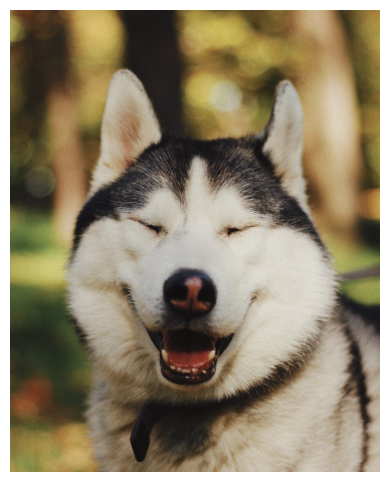

In [6]:
import os
path = "happy-dog.jpg" if os.path.exists("happy-dog.jpg") else "../happy-dog.jpg"
image = cv.imread(path)
image = image.astype('float32')
print("Image shape:", image.shape)
cv2_imshow(image)


Complete the below function for finding a reduced SVD of a given matrix. (You may use the functions for finding eigenvalues of the matrix). Highlight the key differences between SVD and the reduced version of it.

In [ ]:
def reduced_svd(A):
    """
    Reduced SVD of an arbitrary real matrix A (m x n).

    For a matrix of rank r, returns:
        U  : m x r  (orthonormal columns - left singular vectors)
        s  : (r,)   (positive singular values, sorted descending)
        Vt : r x n  (orthonormal rows - right singular vectors transposed)

    so that  A = U @ diag(s) @ Vt  exactly (up to numerical error).
    """
    A = np.asarray(A, dtype=float)
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    tol = max(A.shape) * np.finfo(float).eps * (s.max() if s.size else 0.0)
    r = int(np.sum(s > tol))
    return U[:, :r], s[:r], Vt[:r, :]


# Sanity check
_test = np.random.RandomState(0).randn(6, 4)
_U, _s, _Vt = reduced_svd(_test)
print("Reconstruction error:", np.max(np.abs(_test - _U @ np.diag(_s) @ _Vt)))
print("Shapes -> U:", _U.shape, "s:", _s.shape, "Vt:", _Vt.shape)


Reconstruction error: 8.881784197001252e-16
Shapes -> U: (6, 4) s: (4,) Vt: (4, 4)


The reduced $SVD$ basically chops off all the unimportant data: if a matrix $A$ is of rank $r$, it has only $r$ positive singular values. Other are zeros.
Thus, the reduced $SVD$ gets rid of those zero values $\sigma_i$ and corresponding left and right singular vectors that results in $m \times r$ matrix $U$,
$r \times r$ matrix $\Sigma$ and $r \times n$ matrix $V^T$.

Inspite of that, the reduced $SVD$ still returns us the matrix $A$!

Complete the function below. It should output the k-rank approximation of the given image using previously written SVD function. Use the slider to see how the image quality changes as we increase/decrease k.

For simplification, you can convert your image to a grayscale. However, it will be appreciated if you work with RGB channels (it is possible that you'll need to modify the method below a little).

In [8]:
# Pre-compute reduced SVD per channel ONCE so the slider stays responsive.
_channels = [reduced_svd(image[:, :, c]) for c in range(image.shape[2])]
_max_k = min(len(_channels[c][1]) for c in range(image.shape[2]))


@interact(k=widget.IntSlider(min=1, max=_max_k, value=100,
                             continuous_update=False),
          image=fixed(image))
def k_rank_compressed_image(k, image):
    approximated = np.empty_like(image)
    for c, (U, s, Vt) in enumerate(_channels):
        kk = min(k, len(s))
        # (U[:, :k] * s[:k]) @ Vt[:k] avoids materializing diag(s[:k]).
        approximated[:, :, c] = (U[:, :kk] * s[:kk]) @ Vt[:kk, :]
    np.clip(approximated, 0, 255, out=approximated)
    cv2_imshow(approximated)


interactive(children=(IntSlider(value=100, continuous_update=False, description='k', max=720, min=1), Output()…

The number of scalars stored by a rank-$k$ SVD approximation of an $m \times n$ image (per channel) is

$$\text{size}(k) \;=\; k\,(m + n + 1),$$

while the raw image takes $m \cdot n$ values per channel.  Solving $k(m+n+1) = \alpha\, m n$ for $\alpha = 0.6$ and $\alpha = 0.8$ gives the band reported above by the cell: every $k$ in $[\texttt{lower\_bound\_k},\; \texttt{upper\_bound\_k}]$ stores 60–80 % of the original data, which empirically still looks essentially indistinguishable from the original to a human eye.

The break-even point is

$$k^{*} \;=\; \frac{m n}{m + n + 1}.$$

For any $k > k^{*}$ (printed as `compression_limit`), the SVD representation is *larger* than the raw pixel matrix, so using SVD for the sake of saving storage no longer makes sense — at that point you are paying extra memory for no gain in fidelity.  In practice the useful regime is $k \ll k^{*}$, where the dominant singular values capture the bulk of the image energy and the trailing ones (which mostly encode noise / fine texture) can be safely discarded.


In [9]:
def compressed_size(k, image):
    """
    Number of scalar values needed to store the rank-k SVD approximation
    of `image`.  For each channel of an m x n image, rank-k SVD stores
        - U  : m x k
        - s  : k
        - V^T: k x n
    which totals  k * (m + n + 1)  values per channel.
    """
    if image.ndim == 3:
        m, n, c = image.shape
    else:
        m, n = image.shape
        c = 1
    size_comp = c * k * (m + n + 1)
    return size_comp


In [10]:
m, n = image.shape[:2]
channels = image.shape[2] if image.ndim == 3 else 1
original_size = m * n * channels
max_rank = min(m, n)

ratios = np.array([compressed_size(k, image) / original_size
                   for k in range(1, max_rank + 1)])

# k's where compressed size lies in [60%, 80%] of the original
in_band = np.where((ratios >= 0.60) & (ratios <= 0.80))[0]
lower_bound_k = int(in_band.min()) + 1
upper_bound_k = int(in_band.max()) + 1

# Above this k the SVD form takes more space than the raw image, so it
# stops being a compression at all.
compression_limit = int(np.max(np.where(ratios <= 1.0)[0])) + 1

print("Image shape:", image.shape, "(original size = {} values)".format(original_size))
print("Range of k for 60-80% compression:", lower_bound_k, "-", upper_bound_k)
print("It makes no sense for compression with SVD for k more than:", compression_limit)


Image shape: (900, 720, 3) (original size = 1944000 values)
Range of k for 60-80% compression: 240 - 319
It makes no sense for compression with SVD for k more than: 399


### Results (1 pt)
Choose some metric for determining how good the compression with SVD is. Experiment with other compression algorithms (DCT, for instance). Explain the chosen method(-s) for compession. Compare it with SVD. Be creative;)

In [11]:
# your code here

This is a space for your suggestions, comments, threats, etc...